# Experiment 1 — Jittering Sample-Size Saturation Study

**Question:** for each QUIDA dataset, how many jittered copies add real value before extra copies are just
redundant noise around the same points?

**Why this replaces the "cascade rounds" version.** Jittering is a fixed stochastic transform, not a
trained model, so there is no state to iterate — "rounds" are unnecessary. Worse, the cascade jittered the
*growing pool* each round (jitter of jitter), which is a self-consuming loop: its own current-round
Wasserstein rose every round (IMU 0.079 -> 0.085; Radar 0.500 -> 0.543), i.e. later rounds produced samples
progressively further from the real data (variance inflation / drift), not closer.

**Corrected method (matches Exp 2 VAE / Exp 3 TimeGAN).** Generate N **independent** jittered copies of the
**real** data (fresh noise each copy, fixed sigma, no cascade), sweep N = 1x/2x/3x/5x/8x, average over
seeds, and score every size against the same real reference with the identical metric suite and visuals.
Outputs go to `jitter_size_study/`, so all three augmentation methods are directly comparable.

## 1. Import libraries

In [1]:
from __future__ import annotations
import os, json, pickle, random, warnings, time
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import OneClassSVM
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import cdist, pdist
from scipy.stats import wasserstein_distance

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("NumPy:", np.__version__)

2026-08-24 18:26:35.131273: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787595995.348564  179336 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787595995.400684  179336 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787595995.651655  179336 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787595995.651691  179336 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787595995.651694  179336 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.1
Keras: 3.10.0
NumPy: 1.26.4


## 2. Configuration

In [ ]:
@dataclass
class Config:
    # Preprocessed datasets
    data_dir: Path = field(
        default_factory=lambda: (Path.cwd() / "../Preprocessed_dataset").resolve()
    )

    # Keep generated results inside the current experiment directory
    output_dir: Path = field(
        default_factory=lambda: Path.cwd() / "jitter_size_study"
    )

    dataset_glob: str = "*_raw.npy"
    datasets: dict | None = None

    seed: int = 42

    # --- sample-size sweep ---
    multipliers: tuple = (1, 2, 3, 5, 6, 7, 8, 9, 10)
    n_seeds: int = 5
    recommend_tol: float = 0.05

    # --- jittering ---
    sigma: float = 0.05

    # --- evaluation ---
    const_eps: float = 1e-8
    emb_max_dim: int = 30
    ocsvm_nu: float = 0.1
    dc_k: int = 5
    feat_cap: int = 150
    mmd_cap: int = 800
    pca_plot: bool = True


CFG = Config()

CFG.output_dir.mkdir(parents=True, exist_ok=True)

print("Data:", CFG.data_dir)
print("Output:", CFG.output_dir)
print(
    "Multipliers:", CFG.multipliers,
    "| seeds:", CFG.n_seeds,
    "| sigma:", CFG.sigma
)

Data: /voc/data/data_zain/Dataset
Output: /voc/work/exp_1/jitter_size_study
Multipliers: (1, 2, 3, 5, 6, 7, 8, 9, 10) | seeds: 5 | sigma: 0.05


In [3]:
def set_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    try:
        keras.utils.set_random_seed(seed)
    except AttributeError:
        tf.random.set_seed(seed)

set_seeds(CFG.seed)

## 3. Load the four datasets

In [4]:
def _clean_name(fn):
    s = Path(fn).stem; return s[:-4] if s.endswith("_raw") else s

def discover_datasets(cfg):
    if cfg.datasets:
        items = list(cfg.datasets.items())
        miss = [str(cfg.data_dir/f) for _,f in items if not (cfg.data_dir/f).exists()]
        if miss: raise FileNotFoundError("Missing: " + ", ".join(miss))
    else:
        files = sorted(cfg.data_dir.glob(cfg.dataset_glob), key=lambda q:(q.name.count("_"), q.name))
        if not files: raise FileNotFoundError(f"No files matching {cfg.dataset_glob!r} in {cfg.data_dir}")
        items = [(_clean_name(q.name), q.name) for q in files]
    data={}
    for name,fname in items:
        data[name]=np.load(cfg.data_dir/fname, allow_pickle=False).astype(np.float32)
        print(f"  {name:16s} <- {fname:26s} {data[name].shape}")
    return data
RAW = discover_datasets(CFG)


  X_imu            <- X_imu_raw.npy              (99, 32, 3)
  X_imu_ir         <- X_imu_ir_raw.npy           (99, 32, 771)
  X_imu_radar      <- X_imu_radar_raw.npy        (99, 32, 1137)
  X_imu_ir_radar   <- X_imu_ir_radar_raw.npy     (99, 32, 1905)


## 4. Data validation

In [5]:
def validate_dataset(name, X, cfg):
    assert X.ndim==3, f"{name}: need (N,T,F), got {X.shape}"
    N,T,F=X.shape
    n_nan,n_inf=int(np.isnan(X).sum()),int(np.isinf(X).sum())
    if n_nan or n_inf:
        X=np.where(np.isfinite(X),X,np.nan)
        fm=np.nan_to_num(np.nanmean(X.reshape(-1,F),axis=0)); ii=np.where(~np.isfinite(X)); X[ii]=np.take(fm,ii[2])
        print(f"  ! {name}: imputed {n_nan} NaN / {n_inf} Inf")
    nconst=int((np.ptp(X.reshape(-1,F).astype(np.float64),axis=0)<=cfg.const_eps).sum())
    print(f"  {name:16s} N={N} T={T} F={F} const_cols={nconst} min={X.min():+.1f} max={X.max():+.1f}")
    return X.astype(np.float32)
RAW={n:validate_dataset(n,X,CFG) for n,X in RAW.items()}


  X_imu            N=99 T=32 F=3 const_cols=0 min=-73.4 max=+72.1
  X_imu_ir         N=99 T=32 F=771 const_cols=0 min=-73.4 max=+72.1
  X_imu_radar      N=99 T=32 F=1137 const_cols=294 min=-73.4 max=+1523.0
  X_imu_ir_radar   N=99 T=32 F=1905 const_cols=294 min=-73.4 max=+1523.0


## 5. Jittering + generation

`generate` returns N **independent** jittered copies of the real data: each output sample is one real
sample plus fresh channel-scaled Gaussian noise. No cascade, no self-feeding — every copy is drawn from the
same fixed distribution `real + N(0, (sigma*channel_std)^2)`, so Wasserstein-vs-real stays flat with N
instead of drifting.

In [6]:
def jitter_channelwise(X, sigma, rng):
    # channel-wise Gaussian jitter; noise magnitude = sigma * per-channel std (from X)
    cstd = X.std(axis=(0, 1), keepdims=True)
    return (X + rng.normal(0.0, 1.0, size=X.shape) * sigma * cstd).astype("float32")

def generate(X, n, cfg, rng):
    # n INDEPENDENT jittered copies of the real data (fresh noise; NO cascade / pool-feeding)
    reps = int(np.ceil(n / len(X)))
    base = np.tile(X, (reps, 1, 1))[:n]
    return jitter_channelwise(base, cfg.sigma, rng)

## 6. Evaluation metrics

Distribution/geometry metrics use a shared standardized-PCA embedding of the **real** data (fit once per
dataset, so all sizes are comparable). Per-channel metrics use standardized original features.

In [7]:
def make_embedding(real,cfg):
    R=real.reshape(len(real),-1).astype(np.float64)
    sc=StandardScaler().fit(R); Rs=sc.transform(R)
    k=min(cfg.emb_max_dim,Rs.shape[1],max(2,len(Rs)-1))
    pca=PCA(k,random_state=cfg.seed).fit(Rs) if Rs.shape[1]>k else None
    def emb(X):
        Xs=sc.transform(X.reshape(len(X),-1).astype(np.float64))
        return pca.transform(Xs) if pca is not None else Xs
    return emb

def mmd_rbf(Re,Se,rng,cap):
    X=Re[rng.choice(len(Re),min(cap,len(Re)),replace=False)]
    Y=Se[rng.choice(len(Se),min(cap,len(Se)),replace=False)]
    med=np.median(cdist(X[:200],X[:200])); med=med if med>0 else 1.0
    return float(np.mean([rbf_kernel(X,X,g/med**2).mean()+rbf_kernel(Y,Y,g/med**2).mean()
                          -2*rbf_kernel(X,Y,g/med**2).mean() for g in (0.5,1,2)]))

def ocsvm_metrics(Re,Se,nu):
    oc=OneClassSVM(nu=nu,gamma="scale").fit(Re)
    ri=float((oc.predict(Re)==1).mean()); si=float((oc.predict(Se)==1).mean())
    return abs(ri-si), abs(float(oc.decision_function(Re).mean())-float(oc.decision_function(Se).mean()))

def density_coverage(Re,Se,k):
    k=min(k,len(Re)-1); nn=NearestNeighbors(n_neighbors=k+1).fit(Re)
    radii=nn.kneighbors(Re)[0][:,k]; inside=cdist(Se,Re)<=radii[None,:]
    return float(inside.sum()/(k*len(Se))), float(inside.any(axis=0).mean())

def variance_increase(Re,Se):
    tr=float(Re.var(0).sum()); ta=float(np.vstack([Re,Se]).var(0).sum())
    return float(ta/tr-1.0) if tr>0 else 0.0

def wasserstein_feat(real,synth,rng,cap):
    F=real.shape[-1]; idx=rng.choice(F,min(cap,F),replace=False)
    m=real.reshape(-1,F).mean(0); s=real.reshape(-1,F).std(0); s=np.where(s>1e-8,s,1.0)
    return float(np.mean([wasserstein_distance((real[...,f].ravel()-m[f])/s[f],
                                               (synth[...,f].ravel()-m[f])/s[f]) for f in idx]))

def corr_difference(real,synth,rng,cap):
    F=real.shape[-1]; idx=np.sort(rng.choice(F,min(cap,F),replace=False))
    with np.errstate(invalid="ignore",divide="ignore"):
        Cr=np.corrcoef(real.reshape(-1,F)[:,idx].T); Cs=np.corrcoef(synth.reshape(-1,F)[:,idx].T)
    return float(np.linalg.norm(np.nan_to_num(Cr)-np.nan_to_num(Cs))/len(idx))

def eval_all(real,synth,Re,Se,cfg,rng):
    cg,sg=ocsvm_metrics(Re,Se,cfg.ocsvm_nu); d,c=density_coverage(Re,Se,cfg.dc_k)
    return {"mmd":mmd_rbf(Re,Se,rng,cfg.mmd_cap),"wasserstein":wasserstein_feat(real,synth,rng,cfg.feat_cap),
            "corr_difference":corr_difference(real,synth,rng,cfg.feat_cap),"coverage_gap":cg,"score_gap":sg,
            "variance_increase":variance_increase(Re,Se),"density":d,"coverage":c}


## 7. Run the sample-size sweep

For each dataset x seed: train once, then generate & evaluate at every size. Seed-0 models are kept for
the visualisations.

In [8]:
def run_sweep(cfg):
    records = []; embeds = {}
    for name, X in RAW.items():
        print(f"\n=== {name} ({X.shape}) ===")
        emb = make_embedding(X, cfg); Re = emb(X); embeds[name] = {"Re": Re, "synth": {}}
        n_real = len(X)
        for si in range(cfg.n_seeds):
            rng = np.random.default_rng(cfg.seed + si)
            for m in cfg.multipliers:
                N = int(m * n_real); synth = generate(X, N, cfg, rng); Se = emb(synth)
                records.append({"dataset": name, "multiplier": m, "N": N, "seed": cfg.seed + si,
                                **eval_all(X, synth, Re, Se, cfg, rng)})
                if si == 0: embeds[name]["synth"][N] = Se
        print(f"  {name}: {cfg.n_seeds} seeds x {len(cfg.multipliers)} sizes done")
    return pd.DataFrame(records), embeds, {}

RESULTS, EMB, MODELS = run_sweep(CFG)
RESULTS.to_csv(CFG.output_dir / "sweep_raw.csv", index=False)
print("\nsweep done. rows:", len(RESULTS))


=== X_imu ((99, 32, 3)) ===
  X_imu: 5 seeds x 9 sizes done

=== X_imu_ir ((99, 32, 771)) ===
  X_imu_ir: 5 seeds x 9 sizes done

=== X_imu_radar ((99, 32, 1137)) ===
  X_imu_radar: 5 seeds x 9 sizes done

=== X_imu_ir_radar ((99, 32, 1905)) ===
  X_imu_ir_radar: 5 seeds x 9 sizes done

sweep done. rows: 180


## 8. Aggregate + recommend the saturation size

Metrics are averaged over seeds. A composite score (mean of min-max-normalised, higher-is-better
components: -MMD, -Wasserstein, -Correlation, -coverage_gap, -score_gap, +coverage, +density) captures
both fidelity and diversity. The recommended size is the **smallest** N whose remaining composite gain to
the maximum is below `recommend_tol`.

In [9]:
MET_DIR = {"mmd":0,"wasserstein":0,"corr_difference":0,"coverage_gap":0,"score_gap":0,
           "variance_increase":1,"density":1,"coverage":1}   # 1 = higher better

def aggregate(results):
    g=results.groupby(["dataset","multiplier","N"])
    return g.mean(numeric_only=True).reset_index().drop(columns="seed"), g.std(numeric_only=True).reset_index().drop(columns="seed")

def _norm(x,hi):
    x=np.asarray(x,float); lo,h=np.nanmin(x),np.nanmax(x)
    if h-lo<1e-12: return np.ones_like(x)
    z=(x-lo)/(h-lo); return z if hi else 1-z

def recommend(sub,cfg):
    sub=sub.sort_values("N")
    comps=[_norm(sub[c].values,MET_DIR[c]) for c in ["mmd","wasserstein","corr_difference","coverage_gap","score_gap","coverage","density"]]
    C=np.mean(comps,axis=0); Cmax=C.max(); sizes=sub["N"].values; ri=len(sizes)-1
    for i in range(len(sizes)):
        if Cmax-C[i]<cfg.recommend_tol: ri=i; break
    return C, int(sizes[ri]), int(sub["multiplier"].values[ri])

AGG, AGG_STD = aggregate(RESULTS)
REC={}
for name in RAW:
    sub=AGG[AGG.dataset==name].sort_values("N").reset_index(drop=True)
    C,recN,recM=recommend(sub,CFG); sub=sub.copy(); sub["composite"]=C
    AGG.loc[AGG.dataset==name,"composite"]=C
    REC[name]=dict(N=recN,multiplier=recM,composite_at_rec=float(sub.loc[sub.N==recN,"composite"].iloc[0]))
    print(f"{name:16s} -> recommend N={recN} ({recM}x)  composite={REC[name]['composite_at_rec']:.3f}")


X_imu            -> recommend N=594 (6x)  composite=0.882
X_imu_ir         -> recommend N=594 (6x)  composite=0.822
X_imu_radar      -> recommend N=594 (6x)  composite=0.963
X_imu_ir_radar   -> recommend N=495 (5x)  composite=0.874


## 9. Comparison tables

In [10]:
SHOW=["multiplier","N","mmd","wasserstein","corr_difference","coverage_gap","score_gap",
      "variance_increase","density","coverage","composite"]
for name in RAW:
    sub=AGG[AGG.dataset==name].sort_values("N")[SHOW].reset_index(drop=True)
    sub.insert(0,"pick",np.where(sub.N==REC[name]["N"],"<== recommend",""))
    print(f"\n########## {name}  (recommended N={REC[name]['N']}, {REC[name]['multiplier']}x) ##########")
    display(sub.set_index("multiplier"))
    sub.to_csv(CFG.output_dir/f"{name}_table.csv",index=False)

cross=pd.DataFrame([{"dataset":n,"n_features":RAW[n].shape[-1],"recommend_N":REC[n]["N"],
                     "multiplier":f"{REC[n]['multiplier']}x",
                     **{k:float(AGG[(AGG.dataset==n)&(AGG.N==REC[n]['N'])][k].iloc[0])
                        for k in ["mmd","wasserstein","corr_difference","score_gap","variance_increase","coverage"]}}
                    for n in RAW]).set_index("dataset")
print("\n################ CROSS-DATASET RECOMMENDATION ################")
display(cross); cross.to_csv(CFG.output_dir/"cross_dataset_summary.csv")



########## X_imu  (recommended N=594, 6x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.0003,0.0131,0.0008,0.1515,0.0151,0.0096,0.9927,1.0000,0.1756
2,,198,0.0002,0.0124,0.0006,0.1192,0.0141,0.0102,0.9883,1.0000,0.5829
3,,297,0.0001,0.0121,0.0005,0.1401,0.0131,0.0121,1.0077,1.0000,0.7898
5,,495,0.0001,0.0122,0.0006,0.1430,0.0146,0.0139,0.9979,1.0000,0.5837
6,<== recommend,594,0.0001,0.0121,0.0004,0.1313,0.0135,0.0139,1.0073,1.0000,0.8817
7,,693,0.0001,0.0120,0.0003,0.1362,0.0146,0.0146,1.0032,1.0000,0.7731
8,,792,0.0001,0.0120,0.0004,0.1343,0.0141,0.0149,1.0059,1.0000,0.8196
9,,891,0.0001,0.0119,0.0004,0.1311,0.0138,0.0146,1.0013,1.0000,0.7807
10,,990,0.0002,0.0119,0.0004,0.1269,0.0138,0.0148,1.0053,1.0000,0.7752



########## X_imu_ir  (recommended N=594, 6x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.0000,0.0062,0.0015,0.0202,0.0000,0.0000,1.1030,1.0000,0.4986
2,,198,0.0000,0.0052,0.0013,0.0192,0.0001,-0.0000,1.1071,1.0000,0.5838
3,,297,0.0000,0.0048,0.0012,0.0135,0.0000,0.0000,1.1022,1.0000,0.6958
5,,495,0.0000,0.0044,0.0011,0.0154,0.0000,0.0000,1.1020,1.0000,0.7327
6,<== recommend,594,0.0000,0.0043,0.0011,0.0094,0.0000,-0.0000,1.1009,1.0000,0.8219
7,,693,0.0000,0.0043,0.0011,0.0081,0.0000,0.0000,1.0975,1.0000,0.7465
8,,792,0.0000,0.0042,0.0011,0.0083,0.0000,0.0000,1.0998,1.0000,0.7820
9,,891,0.0001,0.0042,0.0011,0.0058,0.0000,-0.0000,1.0982,1.0000,0.7569
10,,990,0.0001,0.0042,0.0011,0.0048,0.0000,0.0000,1.0981,1.0000,0.6718



########## X_imu_radar  (recommended N=594, 6x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.0000,0.0220,0.0010,0.0343,0.0004,0.0003,1.0865,1.0000,0.3955
2,,198,0.0000,0.0204,0.0008,0.0343,0.0003,0.0002,1.0881,1.0000,0.7397
3,,297,0.0000,0.0209,0.0008,0.0195,0.0004,0.0004,1.0827,1.0000,0.6226
5,,495,0.0000,0.0208,0.0007,0.0307,0.0004,0.0005,1.0861,1.0000,0.6646
6,<== recommend,594,0.0000,0.0205,0.0006,0.0212,0.0003,0.0003,1.0910,1.0000,0.9631
7,,693,0.0000,0.0211,0.0006,0.0309,0.0003,0.0004,1.0874,1.0000,0.7395
8,,792,0.0000,0.0208,0.0007,0.0290,0.0004,0.0004,1.0867,1.0000,0.7003
9,,891,0.0001,0.0213,0.0006,0.0278,0.0004,0.0004,1.0824,1.0000,0.5235
10,,990,0.0002,0.0214,0.0006,0.0313,0.0003,0.0006,1.0887,1.0000,0.5631



########## X_imu_ir_radar  (recommended N=495, 5x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.0000,0.0147,0.0012,0.0162,0.0001,0.0001,1.0857,1.0000,0.3960
2,,198,0.0000,0.0145,0.0009,0.0172,0.0002,0.0001,1.0879,1.0000,0.4772
3,,297,0.0000,0.0143,0.0008,0.0074,0.0001,0.0000,1.0886,1.0000,0.7638
5,<== recommend,495,0.0000,0.0136,0.0007,0.0093,0.0001,0.0001,1.0884,1.0000,0.8738
6,,594,0.0000,0.0137,0.0007,0.0084,0.0002,0.0003,1.0890,1.0000,0.7958
7,,693,0.0000,0.0142,0.0007,0.0058,0.0002,0.0002,1.0906,1.0000,0.8278
8,,792,0.0000,0.0144,0.0007,0.0121,0.0002,0.0002,1.0883,1.0000,0.6129
9,,891,0.0001,0.0138,0.0006,0.0058,0.0001,0.0002,1.0864,1.0000,0.7539
10,,990,0.0001,0.0145,0.0006,0.0111,0.0002,0.0003,1.0872,1.0000,0.5033



################ CROSS-DATASET RECOMMENDATION ################


,n_features,recommend_N,multiplier,mmd,wasserstein,corr_difference,score_gap,variance_increase,coverage
dataset,,,,,,,,,
X_imu,3,594,6x,0.0001,0.0121,0.0004,0.0135,0.0139,1.0000
X_imu_ir,771,594,6x,0.0000,0.0043,0.0011,0.0000,-0.0000,1.0000
X_imu_radar,1137,594,6x,0.0000,0.0205,0.0006,0.0003,0.0003,1.0000
X_imu_ir_radar,1905,495,5x,0.0000,0.0136,0.0007,0.0001,0.0001,1.0000


## 10. Visualizations

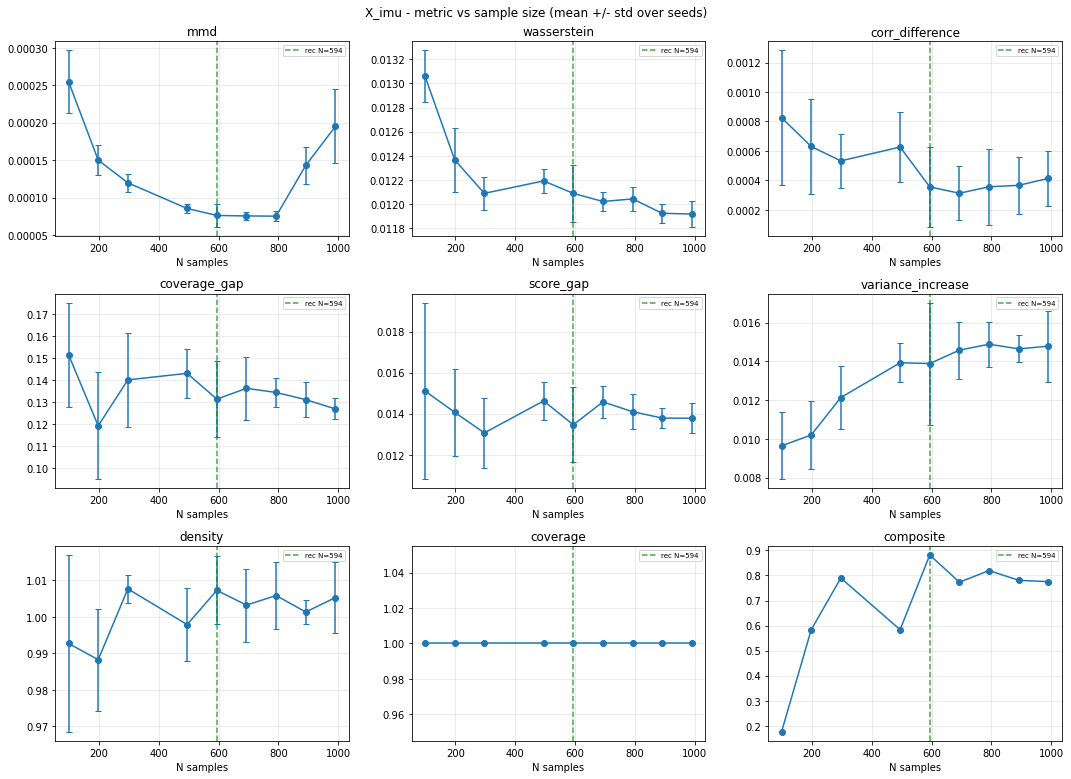

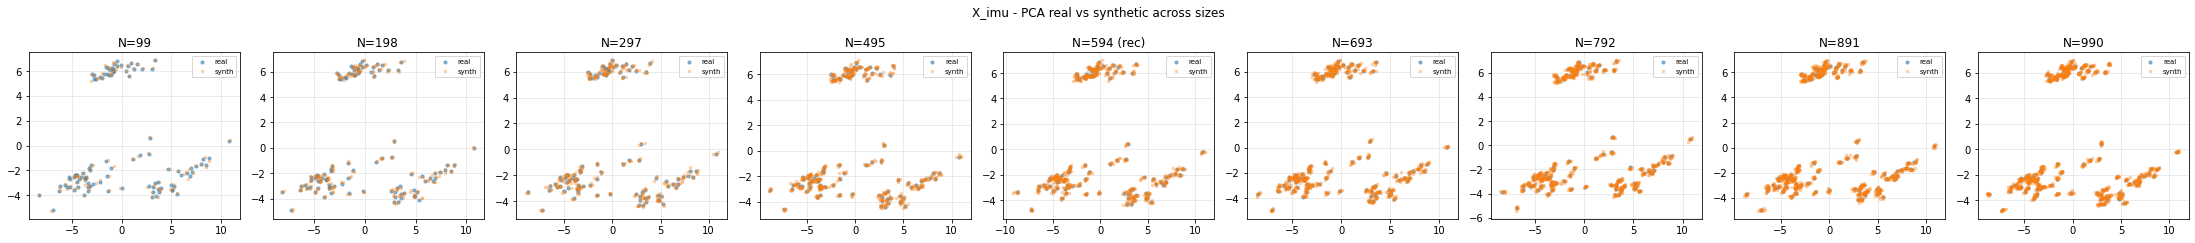

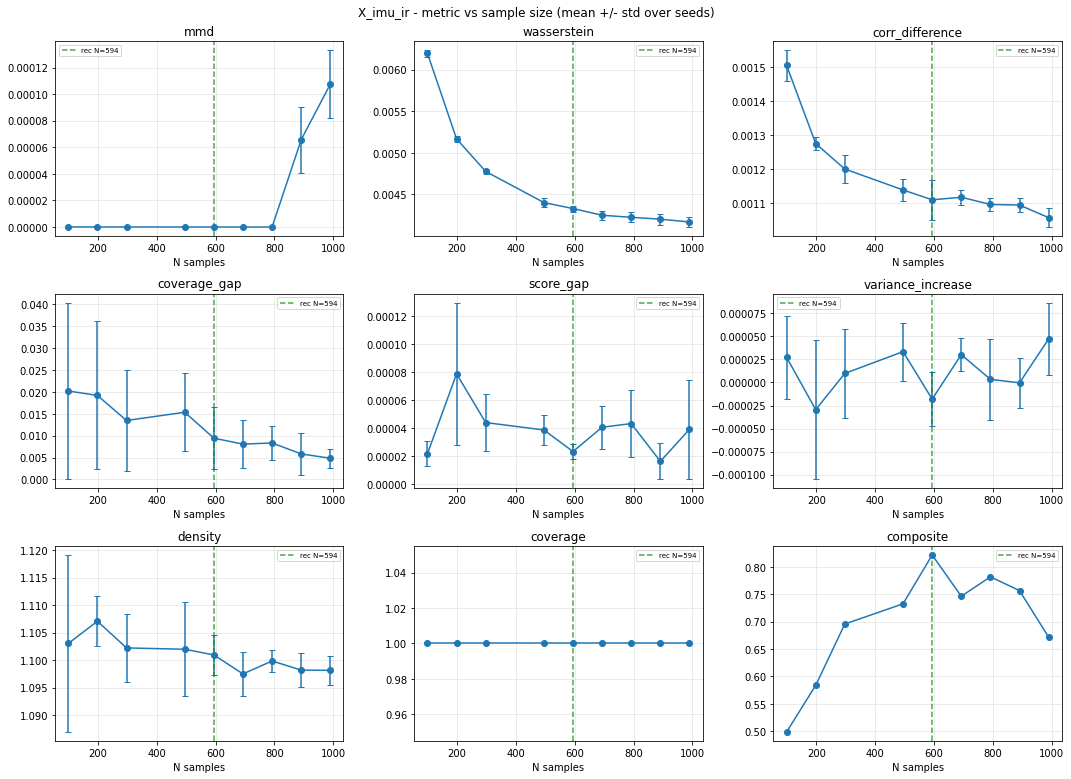

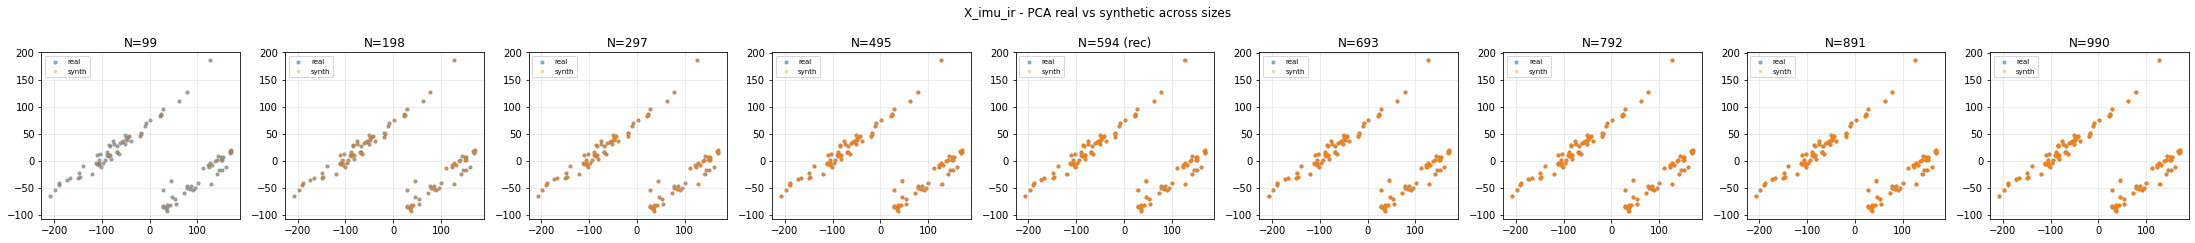

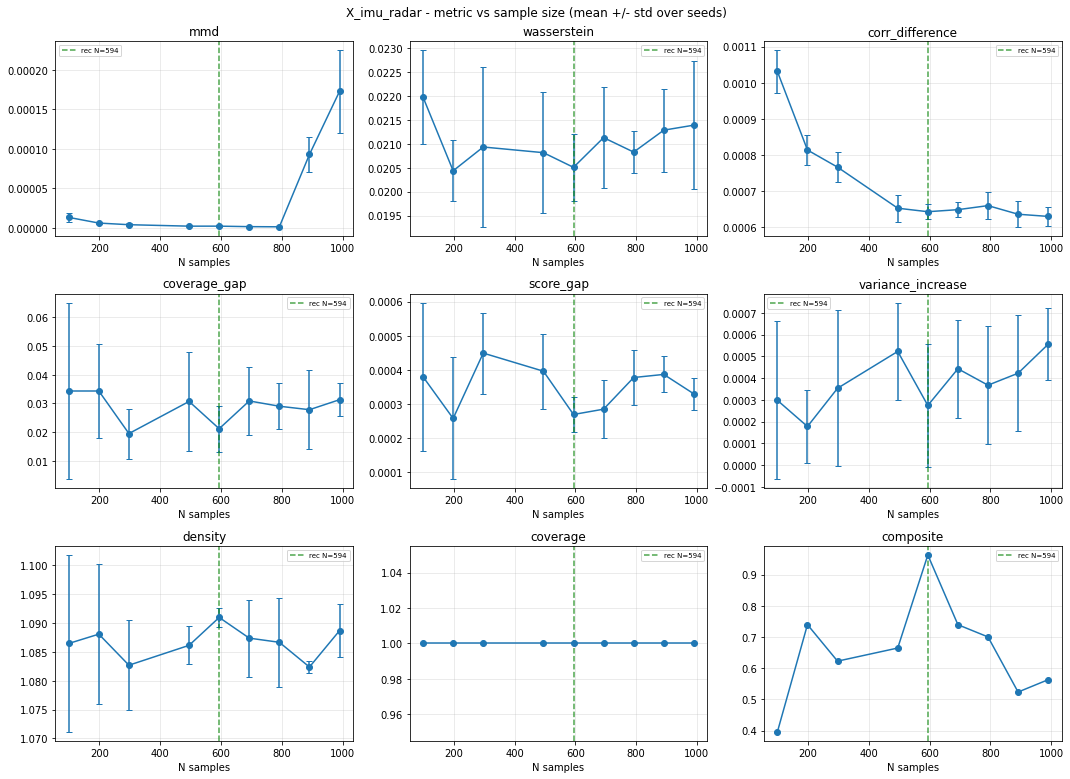

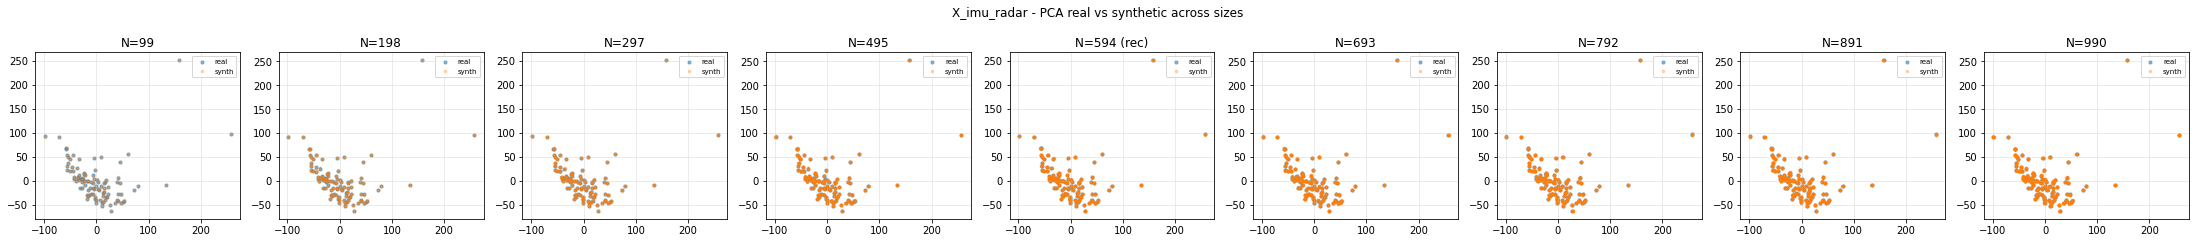

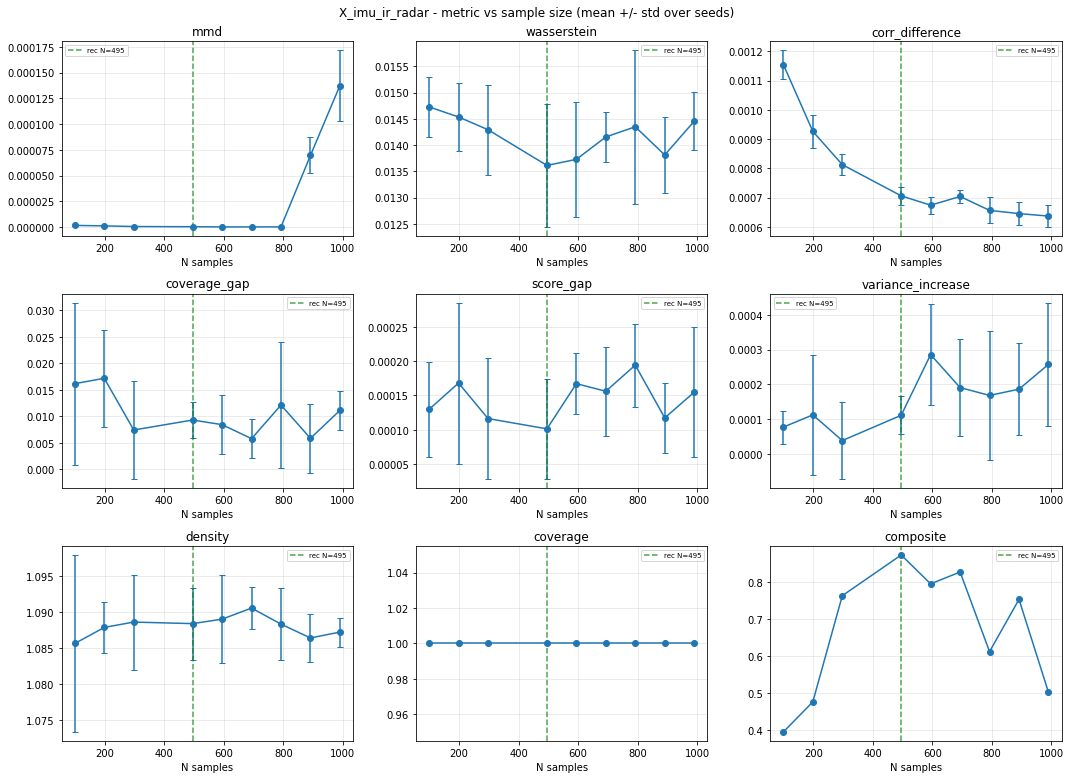

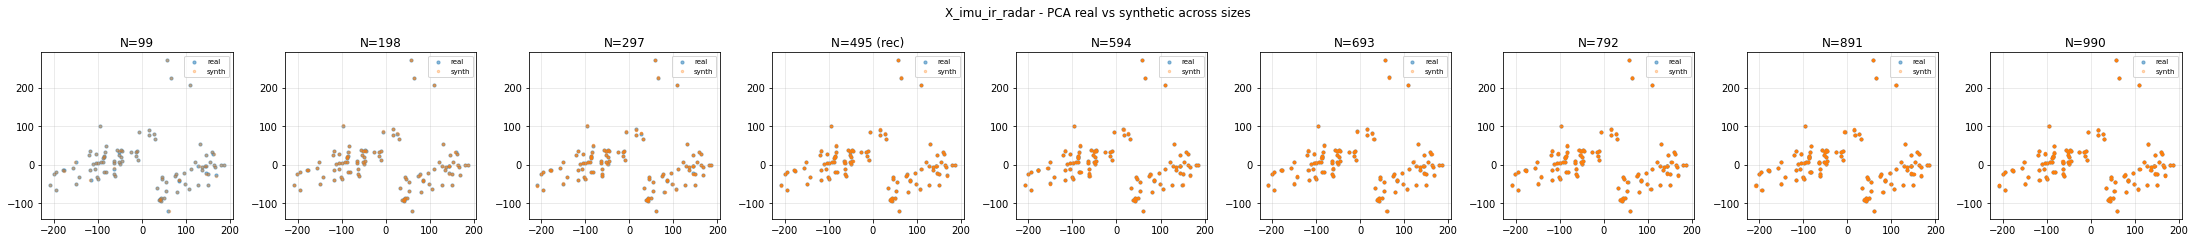

In [11]:
def plot_curves(name):
    sub=AGG[AGG.dataset==name].sort_values("N"); ss=AGG_STD[AGG_STD.dataset==name].sort_values("N")
    mets=["mmd","wasserstein","corr_difference","coverage_gap","score_gap","variance_increase","density","coverage","composite"]
    recN=REC[name]["N"]; fig,axes=plt.subplots(3,3,figsize=(15,11))
    for ax,mt in zip(axes.ravel(),mets):
        x=sub["N"].values; y=sub[mt].values
        yerr=ss[mt].values if mt in ss and mt!="composite" else None
        ax.errorbar(x,y,yerr=yerr,marker="o",capsize=3)
        ax.axvline(recN,color="green",ls="--",alpha=.7,label=f"rec N={recN}")
        ax.set_title(mt); ax.set_xlabel("N samples"); ax.grid(alpha=.3); ax.legend(fontsize=7)
    fig.suptitle(f"{name} - metric vs sample size (mean +/- std over seeds)")
    fig.tight_layout(); fig.savefig(CFG.output_dir/f"{name}_curves.png",dpi=110); plt.show(); plt.close(fig)

def plot_pca(name):
    Re=EMB[name]["Re"]; syn=EMB[name]["synth"]; sizes=sorted(syn)
    fig,axes=plt.subplots(1,len(sizes),figsize=(3.4*len(sizes),3.4),squeeze=False)
    for j,N in enumerate(sizes):
        allp=np.vstack([Re,syn[N]]); p=PCA(2,random_state=CFG.seed).fit_transform(allp)
        axes[0][j].scatter(*p[:len(Re)].T,s=10,alpha=.5,label="real")
        axes[0][j].scatter(*p[len(Re):].T,s=6,alpha=.3,label="synth")
        tag=" (rec)" if N==REC[name]["N"] else ""
        axes[0][j].set_title(f"N={N}{tag}"); axes[0][j].legend(fontsize=7); axes[0][j].grid(alpha=.3)
    fig.suptitle(f"{name} - PCA real vs synthetic across sizes"); fig.tight_layout()
    fig.savefig(CFG.output_dir/f"{name}_pca.png",dpi=110); plt.show(); plt.close(fig)

for name in RAW:
    plot_curves(name); plot_pca(name)


## 11. Save synthetic data at the recommended size + package

In [12]:
import shutil
for name in RAW:
    recN = REC[name]["N"]; rng = np.random.default_rng(CFG.seed)
    synth = generate(RAW[name], recN, CFG, rng)
    d = CFG.output_dir / name; d.mkdir(parents=True, exist_ok=True)
    np.save(d / "synthetic_recommended.npy", synth)
    pd.DataFrame([{"dataset": name, "recommended_N": recN, "multiplier": REC[name]["multiplier"],
                   "n_features": RAW[name].shape[-1], "sigma": CFG.sigma}]).to_csv(d / "metadata.csv", index=False)
    print(f"  {name:16s} saved {synth.shape} at recommended N={recN}")
arch = shutil.make_archive(str(CFG.output_dir), "zip", root_dir=str(CFG.output_dir))
print("\nZipped ->", arch)

  X_imu            saved (594, 32, 3) at recommended N=594
  X_imu_ir         saved (594, 32, 771) at recommended N=594
  X_imu_radar      saved (594, 32, 1137) at recommended N=594
  X_imu_ir_radar   saved (495, 32, 1905) at recommended N=495

Zipped -> /voc/work/exp_1/jitter_size_study.zip


## Reading the results

For each dataset the recommended N is the smallest size where fidelity (MMD / Wasserstein / correlation)
has flattened **and** diversity (coverage / variance increase) has stopped growing — i.e. more samples add
`< recommend_tol` composite quality. Beyond it you are paying compute for near-duplicates.

Caveats: with ~99 real samples jittering samples noise around each real point, so a "recommended size" tells you how
much to draw before returns vanish, not how to exceed the data-scarcity ceiling. The knee is averaged over
`n_seeds` splits; raise `n_seeds` to 5 for a tighter estimate. The real reference here is the full real set
(consistent across sizes); the study measures **relative** saturation, not absolute fidelity.

## 12. Repeated-run stability analysis — robust final recommendation

Sections 7-11 produce one recommendation per dataset from a single full
**Generation -> Evaluation -> Recommendation** pass. To measure how stable that
recommendation is, we now repeat the **entire existing pipeline** `N_REPEATS`
times as independent runs, reusing `run_sweep`, `aggregate` and `recommend`
**unchanged** — the existing evaluation stays the sole authority for each run's
recommendation. Each run gets its own seed offset (`CFG.seed + rep*REP_SEED_STRIDE`),
so the runs are independent yet fully reproducible; run 0 keeps the original
`CFG.seed`, so it reproduces the single-pass result and acts as an anchor.

For every dataset we then collect the per-run recommended multiplier, take the
**mean** across runs, and snap that mean to the **nearest multiplier actually
generated in the sweep grid** (`CFG.multipliers`). That snapped multiplier is the
robust final representative recommendation. *Example:* runs recommending
`x4, x6, x8, x5, x6` give mean `5.8`, whose nearest available multiplier is `x6`.

Change `N_REPEATS` below to set how many independent repetitions to run. Note:
each repetition re-runs the full sweep, so wall-clock time scales roughly linearly
with `N_REPEATS`. All existing single-pass outputs are preserved untouched; the
robust results are written to new files (`*_repeated_final.npy`,
`metadata_repeated.csv`, `repeated_run_stability.csv`).

In [13]:
# --- Repeated-run stability configuration (change N_REPEATS to taste) ---
N_REPEATS = 5          # number of independent Generation -> Evaluation -> Recommendation runs
REP_SEED_STRIDE = 1000  # seed spacing between runs (keeps each run's seed block independent)

print(f"Repeated-run analysis: {N_REPEATS} independent runs "
      f"(seeds {CFG.seed} + rep*{REP_SEED_STRIDE}), reusing the existing pipeline unchanged.")

Repeated-run analysis: 5 independent runs (seeds 42 + rep*1000), reusing the existing pipeline unchanged.


In [14]:
from dataclasses import replace as _dc_replace

# One record per dataset: the recommendation + full evaluation trace from every repetition.
REPEAT_RESULTS = {name: {"seeds": [], "rec_multiplier": [], "rec_N": [],
                         "composite_at_rec": [], "composite_grid": [],
                         "grid_multipliers": None, "grid_N": None,
                         "metric_frames": []} for name in RAW}

for rep in range(N_REPEATS):
    rep_seed = CFG.seed + rep * REP_SEED_STRIDE     # run 0 == CFG.seed -> reproduces the single pass
    cfg_rep = _dc_replace(CFG, seed=rep_seed)       # identical config, independent seed
    set_seeds(rep_seed)                             # keep global RNG state reproducible per run

    # ----- existing pipeline, executed exactly as-is -----
    results_rep, _emb_rep, _models_rep = run_sweep(cfg_rep)      # Generation + Evaluation
    agg_rep, _agg_std_rep = aggregate(results_rep)              # Aggregate over seeds

    for name in RAW:
        sub = agg_rep[agg_rep.dataset == name].sort_values("N").reset_index(drop=True)
        C, recN, recM = recommend(sub, cfg_rep)                # Recommendation (unchanged authority)
        store = REPEAT_RESULTS[name]
        store["seeds"].append(rep_seed)
        store["rec_multiplier"].append(int(recM))
        store["rec_N"].append(int(recN))
        store["composite_at_rec"].append(float(C[sub["N"].values == recN][0]))
        store["composite_grid"].append(np.asarray(C, float))
        sub_c = sub.copy(); sub_c["composite"] = C; sub_c["rep"] = rep
        store["metric_frames"].append(sub_c)
        if store["grid_multipliers"] is None:
            store["grid_multipliers"] = sub["multiplier"].values.astype(int)
            store["grid_N"] = sub["N"].values.astype(int)

    print(f"  rep {rep + 1:>2}/{N_REPEATS} (seed {rep_seed}): "
          + ", ".join(f"{name}->{REPEAT_RESULTS[name]['rec_multiplier'][-1]}x" for name in RAW))

set_seeds(CFG.seed)   # restore the original global seed after the repeated runs
print(f"\nrepeated runs done: {N_REPEATS} x full pipeline over {len(RAW)} datasets")


=== X_imu ((99, 32, 3)) ===
  X_imu: 5 seeds x 9 sizes done

=== X_imu_ir ((99, 32, 771)) ===
  X_imu_ir: 5 seeds x 9 sizes done

=== X_imu_radar ((99, 32, 1137)) ===
  X_imu_radar: 5 seeds x 9 sizes done

=== X_imu_ir_radar ((99, 32, 1905)) ===
  X_imu_ir_radar: 5 seeds x 9 sizes done
  rep  1/5 (seed 42): X_imu->6x, X_imu_ir->6x, X_imu_radar->6x, X_imu_ir_radar->5x

=== X_imu ((99, 32, 3)) ===
  X_imu: 5 seeds x 9 sizes done

=== X_imu_ir ((99, 32, 771)) ===
  X_imu_ir: 5 seeds x 9 sizes done

=== X_imu_radar ((99, 32, 1137)) ===
  X_imu_radar: 5 seeds x 9 sizes done

=== X_imu_ir_radar ((99, 32, 1905)) ===
  X_imu_ir_radar: 5 seeds x 9 sizes done
  rep  2/5 (seed 1042): X_imu->8x, X_imu_ir->7x, X_imu_radar->2x, X_imu_ir_radar->5x

=== X_imu ((99, 32, 3)) ===
  X_imu: 5 seeds x 9 sizes done

=== X_imu_ir ((99, 32, 771)) ===
  X_imu_ir: 5 seeds x 9 sizes done

=== X_imu_radar ((99, 32, 1137)) ===
  X_imu_radar: 5 seeds x 9 sizes done

=== X_imu_ir_radar ((99, 32, 1905)) ===
  X_imu_i

In [15]:
def _nearest_grid_multiplier(mean_val, grid):
    # nearest multiplier that was actually generated; ties resolve to the smaller (conservative) one
    grid = np.asarray(sorted(set(int(g) for g in grid)))
    return int(grid[int(np.argmin(np.abs(grid - float(mean_val))))])

REPEAT_SUMMARY_ROWS = []
REPEAT_FINAL = {}   # name -> robust final selection

for name in RAW:
    store = REPEAT_RESULTS[name]
    recs = np.asarray(store["rec_multiplier"], float)
    grid_mults = store["grid_multipliers"]; grid_N = store["grid_N"]

    mean_rec = float(recs.mean())                                  # mean recommendation across runs
    sel_mult = _nearest_grid_multiplier(mean_rec, grid_mults)      # snap to nearest generated multiplier
    sel_N = int(grid_N[list(grid_mults).index(sel_mult)])

    # mean composite (existing evaluation score) across runs at the selected multiplier
    comp_grid = np.vstack(store["composite_grid"])                 # (N_REPEATS, n_grid)
    gi = int(list(grid_mults).index(sel_mult))
    mean_comp_at_sel = float(comp_grid[:, gi].mean())

    # mean of the raw evaluation metrics across runs at the selected multiplier
    frames = pd.concat(store["metric_frames"], ignore_index=True)
    sel_metrics = frames[frames["multiplier"] == sel_mult].mean(numeric_only=True)

    REPEAT_FINAL[name] = {
        "mean_multiplier": mean_rec, "selected_multiplier": sel_mult, "selected_N": sel_N,
        "mean_composite_at_selected": mean_comp_at_sel,
        "per_rep_multipliers": [int(m) for m in store["rec_multiplier"]],
        "single_pass_multiplier": int(REC[name]["multiplier"]), "single_pass_N": int(REC[name]["N"]),
    }
    REPEAT_SUMMARY_ROWS.append({
        "dataset": name, "n_repeats": N_REPEATS,
        "per_rep_multipliers": " ".join(f"{m}x" for m in store["rec_multiplier"]),
        "mean_multiplier": round(mean_rec, 3), "selected_multiplier": f"{sel_mult}x",
        "selected_N": sel_N, "single_pass_multiplier": f"{REC[name]['multiplier']}x",
        "mean_composite_at_selected": round(mean_comp_at_sel, 4),
        "mmd": float(sel_metrics.get("mmd", np.nan)),
        "wasserstein": float(sel_metrics.get("wasserstein", np.nan)),
        "coverage": float(sel_metrics.get("coverage", np.nan)),
    })

REPEAT_SUMMARY = pd.DataFrame(REPEAT_SUMMARY_ROWS).set_index("dataset")
REPEAT_SUMMARY.to_csv(CFG.output_dir / "repeated_run_stability.csv")

# persist every per-run evaluation table too (all relevant evaluation results)
per_rep_all = pd.concat([f for name in RAW for f in REPEAT_RESULTS[name]["metric_frames"]],
                        ignore_index=True)
per_rep_all.to_csv(CFG.output_dir / "repeated_run_per_rep_metrics.csv", index=False)

print("################ REPEATED-RUN STABILITY SUMMARY ################")
display(REPEAT_SUMMARY)

################ REPEATED-RUN STABILITY SUMMARY ################


,n_repeats,per_rep_multipliers,mean_multiplier,selected_multiplier,selected_N,single_pass_multiplier,mean_composite_at_selected,mmd,wasserstein,coverage
dataset,,,,,,,,,,
X_imu,5,6x 8x 2x 6x 7x,5.8000,6x,594,6x,0.7398,0.0001,0.0121,1.0000
X_imu_ir,5,6x 7x 2x 8x 7x,6.0000,6x,594,6x,0.7984,0.0000,0.0043,1.0000
X_imu_radar,5,6x 2x 5x 5x 5x,4.6000,5x,495,6x,0.7376,0.0000,0.0210,1.0000
X_imu_ir_radar,5,5x 5x 6x 3x 6x,5.0000,5x,495,5x,0.7182,0.0000,0.0142,1.0000


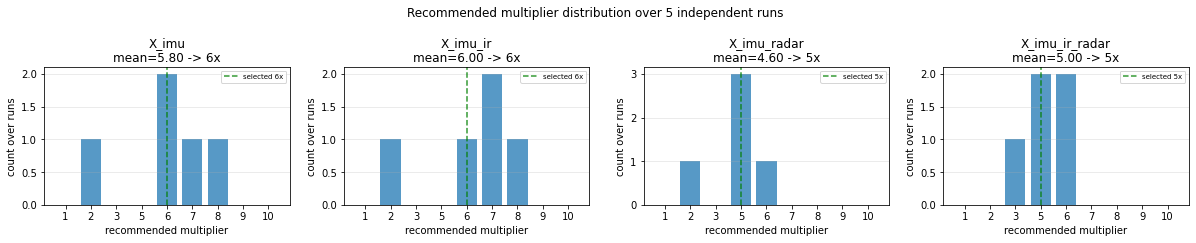

In [16]:
# distribution of the recommended multiplier over the independent runs (per dataset)
grid_all = sorted(set(int(m) for m in CFG.multipliers))
fig, axes = plt.subplots(1, len(RAW), figsize=(4.2 * len(RAW), 3.4), squeeze=False)
for ax, name in zip(axes[0], RAW):
    recs = REPEAT_RESULTS[name]["rec_multiplier"]
    counts = [recs.count(m) for m in grid_all]
    ax.bar([str(m) for m in grid_all], counts, alpha=.75)
    sel = REPEAT_FINAL[name]["selected_multiplier"]; mean_rec = REPEAT_FINAL[name]["mean_multiplier"]
    ax.axvline(grid_all.index(sel), color="green", ls="--", alpha=.8, label=f"selected {sel}x")
    ax.set_title(f"{name}\nmean={mean_rec:.2f} -> {sel}x")
    ax.set_xlabel("recommended multiplier"); ax.set_ylabel("count over runs")
    ax.grid(alpha=.3, axis="y"); ax.legend(fontsize=7)
fig.suptitle(f"Recommended multiplier distribution over {N_REPEATS} independent runs")
fig.tight_layout(); fig.savefig(CFG.output_dir / "repeated_run_stability.png", dpi=110)
plt.show(); plt.close(fig)

In [17]:
# Regenerate + save the robust final dataset at the selected multiplier, then report.
# NOTE: new filenames only -- the existing single-pass outputs are left untouched.
print("################ FINAL REPRESENTATIVE RECOMMENDATION (repeated-run) ################\n")
for name in RAW:
    fin = REPEAT_FINAL[name]
    sel_N = fin["selected_N"]; sel_mult = fin["selected_multiplier"]

    rng = np.random.default_rng(CFG.seed)                 # reproducible, same generator as section 11
    synth = generate(RAW[name], sel_N, CFG, rng)

    d = CFG.output_dir / name; d.mkdir(parents=True, exist_ok=True)
    final_path = d / "synthetic_repeated_final.npy"
    np.save(final_path, synth)
    pd.DataFrame([{
        "dataset": name, "n_repeats": N_REPEATS,
        "per_rep_multipliers": " ".join(f"{m}x" for m in fin["per_rep_multipliers"]),
        "mean_multiplier": fin["mean_multiplier"],
        "selected_multiplier": sel_mult, "selected_N": sel_N,
        "mean_composite_at_selected": fin["mean_composite_at_selected"],
        "single_pass_multiplier": fin["single_pass_multiplier"],
        "single_pass_N": fin["single_pass_N"],
        "n_features": RAW[name].shape[-1], "sigma": CFG.sigma,
    }]).to_csv(d / "metadata_repeated.csv", index=False)

    print(f"=== {name} ===")
    print(f"  per-run recommendations : {' '.join(f'{m}x' for m in fin['per_rep_multipliers'])}")
    print(f"  mean recommendation     : {fin['mean_multiplier']:.3f}x")
    print(f"  selected robust final   : {sel_mult}x  (N={sel_N})")
    print(f"  single-pass baseline    : {fin['single_pass_multiplier']}x (N={fin['single_pass_N']})")
    print(f"  mean composite @ final  : {fin['mean_composite_at_selected']:.4f}")
    print(f"  final dataset saved     : {tuple(synth.shape)} -> {final_path}\n")

print("Existing single-pass outputs preserved. Robust final outputs written as")
print("  <dataset>/synthetic_repeated_final.npy, <dataset>/metadata_repeated.csv,")
print("  repeated_run_stability.csv, repeated_run_per_rep_metrics.csv, repeated_run_stability.png")

################ FINAL REPRESENTATIVE RECOMMENDATION (repeated-run) ################

=== X_imu ===
  per-run recommendations : 6x 8x 2x 6x 7x
  mean recommendation     : 5.800x
  selected robust final   : 6x  (N=594)
  single-pass baseline    : 6x (N=594)
  mean composite @ final  : 0.7398
  final dataset saved     : (594, 32, 3) -> /voc/work/exp_1/jitter_size_study/X_imu/synthetic_repeated_final.npy

=== X_imu_ir ===
  per-run recommendations : 6x 7x 2x 8x 7x
  mean recommendation     : 6.000x
  selected robust final   : 6x  (N=594)
  single-pass baseline    : 6x (N=594)
  mean composite @ final  : 0.7984
  final dataset saved     : (594, 32, 771) -> /voc/work/exp_1/jitter_size_study/X_imu_ir/synthetic_repeated_final.npy

=== X_imu_radar ===
  per-run recommendations : 6x 2x 5x 5x 5x
  mean recommendation     : 4.600x
  selected robust final   : 5x  (N=495)
  single-pass baseline    : 6x (N=594)
  mean composite @ final  : 0.7376
  final dataset saved     : (495, 32, 1137) -> /voc/wo